In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.unicode_minus"] = False

CSV_PATH = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap200_20260320_221238_496409_8205.csv")
PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "experiment1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.head()

,episode,hotel_revenue,ota_profit,bookings_online,bookings_offline,total_subsidy,avg_subsidy_amount,avg_subsidy_ratio
0,1,3.969267e+06,200813.836066,15886,21576,157075.064988,9.887641,0.401002
1,2,4.214649e+06,213779.934403,17118,23513,163700.278583,9.563049,0.561632
2,3,4.343208e+06,224501.265667,18113,24466,166151.084176,9.173030,0.164911
3,4,4.538430e+06,232254.218521,18520,26549,164976.943749,8.908042,0.436035
4,5,4.605865e+06,229333.921601,18192,27756,157822.738177,8.675392,0.627247


In [13]:
required_cols = [
    "episode",
    "hotel_revenue",
    "ota_profit",
    "bookings_online",
    "bookings_offline",
    "total_subsidy",
    "avg_subsidy_amount",
    "avg_subsidy_ratio",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"CSV缺少字段: {missing}")

df = df.sort_values("episode").reset_index(drop=True)

df["system_profit"] = df["hotel_revenue"] + df["ota_profit"]
df["bookings_total"] = df["bookings_online"] + df["bookings_offline"]
df["online_ratio"] = df["bookings_online"] / df["bookings_total"].replace(0, np.nan)

ROLLING_WINDOW = 10

for col in [
    "hotel_revenue",
    "ota_profit",
    "system_profit",
    "bookings_online",
    "bookings_offline",
    "online_ratio",
    "avg_subsidy_ratio",
    "avg_subsidy_amount",
    "total_subsidy",
]:
    df[f"{col}_ma"] = df[col].rolling(ROLLING_WINDOW, min_periods=1).mean()

df.tail()

,episode,hotel_revenue,ota_profit,bookings_online,bookings_offline,total_subsidy,avg_subsidy_amount,avg_subsidy_ratio,system_profit,bookings_total,online_ratio,hotel_revenue_ma,ota_profit_ma,system_profit_ma,bookings_online_ma,bookings_offline_ma,online_ratio_ma,avg_subsidy_ratio_ma,avg_subsidy_amount_ma,total_subsidy_ma
245,246,5.161875e+06,258660.104131,16545,40028,50865.885218,3.074396,0.335521,5.420535e+06,56573,0.292454,5.182777e+06,259572.530886,5.442349e+06,16597.7,40065.2,0.292920,0.364616,3.106127,51554.626441
246,247,5.182970e+06,265599.758613,17048,39946,51613.075635,3.027515,0.303250,5.448570e+06,56994,0.299119,5.179530e+06,260247.972170,5.439778e+06,16642.7,40020.5,0.293708,0.352020,3.095619,51516.454177
247,248,5.176288e+06,259974.845815,16506,40126,49451.805023,2.995990,0.440279,5.436263e+06,56632,0.291461,5.179556e+06,260218.291772,5.439775e+06,16630.5,40045.4,0.293427,0.364117,3.084733,51298.880692
248,249,5.167136e+06,259515.512394,16534,40076,50842.931492,3.075053,0.340021,5.426652e+06,56610,0.292069,5.178591e+06,260094.479853,5.438685e+06,16620.4,40067.1,0.293188,0.361114,3.081001,51205.746598
249,250,5.164286e+06,254142.373347,16188,40239,49972.555026,3.087012,0.371471,5.418428e+06,56427,0.286884,5.176326e+06,259220.229769,5.435546e+06,16561.3,40092.9,0.292315,0.368127,3.080493,51014.782940


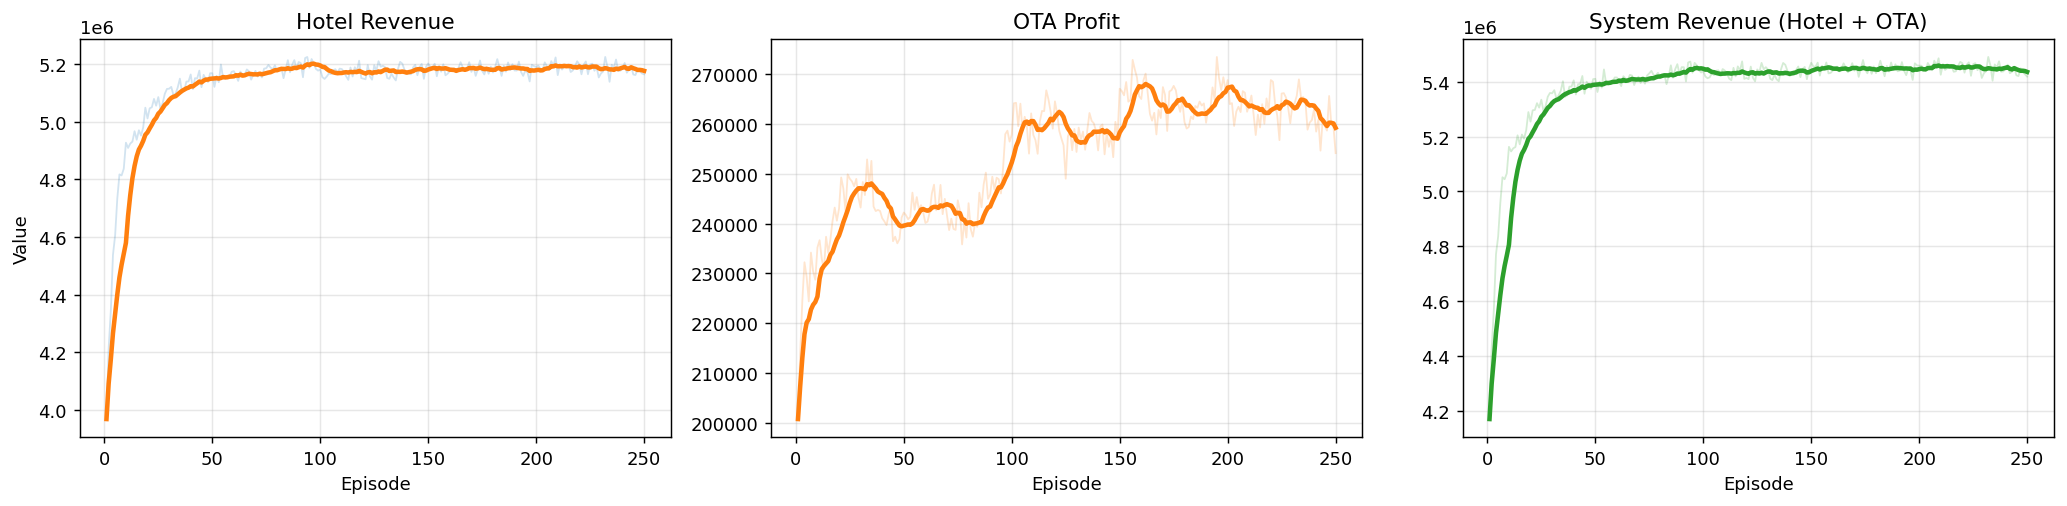

(PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/A1_triptych_hotel_ota_system.png'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/A1_triptych_hotel_ota_system.pdf'))

In [14]:
import numpy as np
import matplotlib.pyplot as plt

if "system_profit" not in df.columns:
    df["system_profit"] = df["hotel_revenue"] + df["ota_profit"]

x = df["episode"]

ROLLING_WINDOW = 10
hotel_ma = df["hotel_revenue"].rolling(ROLLING_WINDOW, min_periods=1).mean()
ota_ma = df["ota_profit"].rolling(ROLLING_WINDOW, min_periods=1).mean()
sys_ma = df["system_profit"].rolling(ROLLING_WINDOW, min_periods=1).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].plot(x, df["hotel_revenue"], alpha=0.20, linewidth=1)
axes[0].plot(x, hotel_ma, linewidth=2.5)
axes[0].set_title("Hotel Revenue")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df["ota_profit"], alpha=0.20, linewidth=1, color="tab:orange")
axes[1].plot(x, ota_ma, linewidth=2.5, color="tab:orange")
axes[1].set_title("OTA Profit")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, df["system_profit"], alpha=0.20, linewidth=1, color="tab:green")
axes[2].plot(x, sys_ma, linewidth=2.5, color="tab:green")
axes[2].set_title("System Revenue (Hotel + OTA)")
axes[2].set_xlabel("Episode")
axes[2].grid(True, alpha=0.3)

#fig.suptitle(f"Experiment1: Convergence Curves (MA{ROLLING_WINDOW})", y=1.02)
fig.tight_layout()

save_path_png = FIG_DIR / "A1_triptych_hotel_ota_system.png"
save_path_pdf = FIG_DIR / "A1_triptych_hotel_ota_system.pdf"
fig.savefig(save_path_png)
fig.savefig(save_path_pdf)
plt.show()

save_path_png, save_path_pdf

In [15]:
from pathlib import Path
import json
import ast
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing")
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "experiment1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CAPACITY = 200

MIN_VISITS_PER_STATE = 5
MIN_TOTAL_VISITS_PER_CELL = 30

season_name = {0: "Off-peak", 1: "Shoulder", 2: "Peak"}
weekday_name = ["Weekday", "Weekend"]
inv_name = ["Low inv", "Mid inv", "High inv"]

def newest_file(paths):
    paths = list(paths)
    if not paths:
        return None
    return max(paths, key=lambda p: p.stat().st_mtime)

def find_latest_model_file(kind: str, capacity: int):
    patterns = [
        f"{kind}_cap{capacity}_*_agent_*.json",
        f"{kind}_agent_*.json",
    ]
    for pat in patterns:
        cand = list(MODELS_DIR.glob(pat))
        if cand:
            return newest_file(cand)
    return None

def _parse_int_key(k):
    if isinstance(k, int):
        return k
    if isinstance(k, str) and k.strip().isdigit():
        return int(k.strip())
    if isinstance(k, str):
        try:
            obj = ast.literal_eval(k)
            if isinstance(obj, int):
                return int(obj)
        except Exception:
            return None
    return None

def load_means_and_visits(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means_key = None
    visits_key = None

    for k, v in d.items():
        if isinstance(v, dict) and ("means" in k.lower()):
            means_key = k
        if isinstance(v, dict) and (("visit" in k.lower()) or ("state_visit" in k.lower())):
            visits_key = k

    if means_key is None:
        raise ValueError(f"找不到 means 字段: {json_path.name}，keys={list(d.keys())}")

    means_raw = d[means_key]
    means = {}
    for k, v in means_raw.items():
        idx = _parse_int_key(k)
        if idx is not None:
            means[idx] = float(v)

    visits = {}
    if visits_key is not None:
        visits_raw = d[visits_key]
        for k, v in visits_raw.items():
            idx = _parse_int_key(k)
            if idx is not None:
                visits[idx] = int(v)

    return means, visits, means_key, visits_key

hotel_online_path = find_latest_model_file("hotel_online", CAPACITY)
hotel_offline_path = find_latest_model_file("hotel_offline", CAPACITY)
ota_path = find_latest_model_file("ota", CAPACITY)

hotel_online_path, hotel_offline_path, ota_path

(PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/hotel_online_cap200_20260320_221238_496409_8205_agent_20260320_221238.json'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/hotel_offline_cap200_20260320_221238_496409_8205_agent_20260320_221238.json'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/ota_cap200_20260320_221238_496409_8205_agent_20260320_221238.json'))

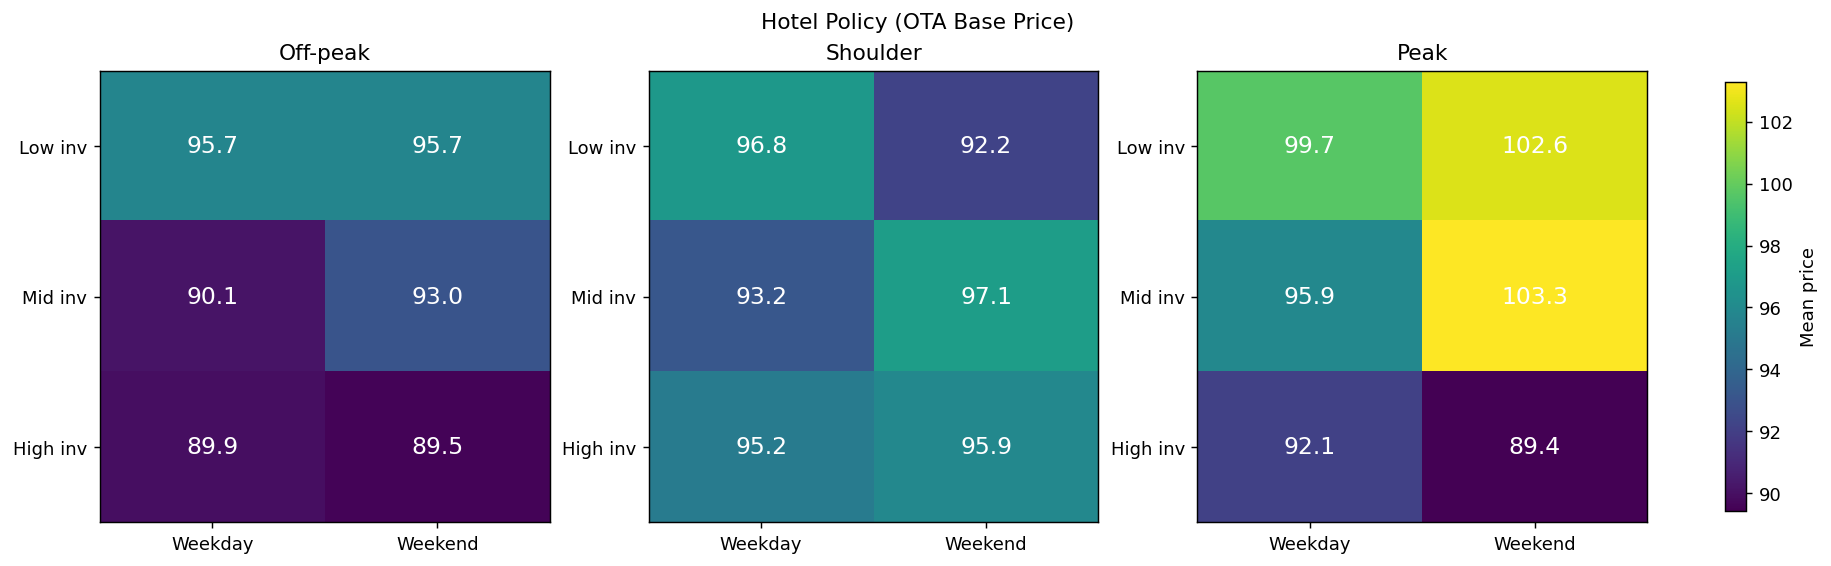

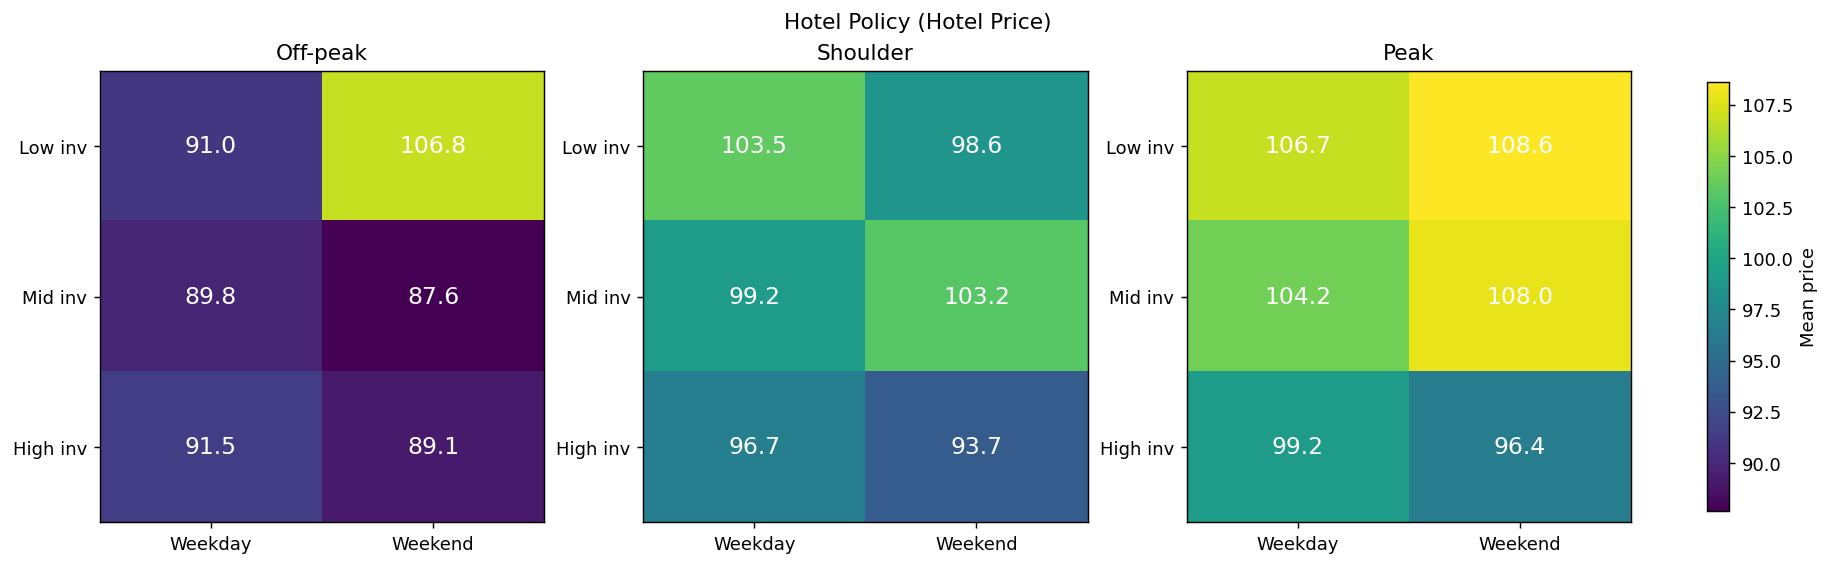

(PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/C1_hotel_offline_heatmap_weighted.png'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/C1_hotel_offline_heatmap_weighted.pdf'))

In [16]:
def hotel_decode_state(state_idx: int, n_stages: int):
    stage_id = state_idx % n_stages
    base = state_idx // n_stages
    inventory_level = base // 6
    rem = base % 6
    season = rem // 2
    weekday = rem % 2
    return int(inventory_level), int(season), int(weekday), int(stage_id)

def hotel_weighted_mats(means: dict, visits: dict, n_stages: int):
    mats = {s: np.full((3, 2), np.nan, dtype=float) for s in [0, 1, 2]}
    mats_cnt = {s: np.zeros((3, 2), dtype=int) for s in [0, 1, 2]}

    acc = {}
    for state_idx, val in means.items():
        c = int(visits.get(state_idx, 0))
        if c < MIN_VISITS_PER_STATE:
            continue

        inv, season, weekday, stage = hotel_decode_state(state_idx, n_stages)
        if inv not in [0,1,2] or season not in [0,1,2] or weekday not in [0,1]:
            continue

        key = (season, inv, weekday)
        if key not in acc:
            acc[key] = {"sum": 0.0, "cnt": 0}
        acc[key]["sum"] += float(val) * c
        acc[key]["cnt"] += c

    for (season, inv, weekday), v in acc.items():
        if v["cnt"] < MIN_TOTAL_VISITS_PER_CELL:
            continue
        mats[season][inv, weekday] = v["sum"] / v["cnt"]
        mats_cnt[season][inv, weekday] = v["cnt"]

    return mats, mats_cnt

def plot_heatmaps_with_counts(mats, mats_cnt, title, out_name, cmap="viridis"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    vmin = np.nanmin([np.nanmin(m) for m in mats.values()])
    vmax = np.nanmax([np.nanmax(m) for m in mats.values()])

    for i, season in enumerate([0, 1, 2]):
        ax = axes[i]
        im = ax.imshow(mats[season], vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
        ax.set_title(season_name[season])
        ax.set_xticks([0, 1], labels=weekday_name)
        ax.set_yticks([0, 1, 2], labels=inv_name)

        for r in range(3):
            for c in range(2):
                v = mats[season][r, c]
                cnt = mats_cnt[season][r, c]
                if not np.isnan(v):
                    ax.text(c, r, f"{v:.1f}", ha="center", va="center", color="white", fontsize=13)

    fig.suptitle(title, y=1.05)
    cbar = fig.colorbar(im, ax=axes, shrink=0.95)
    cbar.set_label("Mean price")

    png = FIG_DIR / f"{out_name}.png"
    pdf = FIG_DIR / f"{out_name}.pdf"
    fig.savefig(png, dpi=300)
    fig.savefig(pdf, dpi=300)
    plt.show()
    return png, pdf

online_means, online_visits, _, _ = load_means_and_visits(hotel_online_path)
offline_means, offline_visits, _, _ = load_means_and_visits(hotel_offline_path)

# 你在训练里 n_stages = len(buckets)，这里如果你要严格一致，把它设成你实验的桶数
# 如果你现在不确定，就用：N_STAGES = 8（对应默认 "0|1|2-3|4-6|7-13|14-29|30-59|60-90"）
N_STAGES = 8

online_mats, online_mats_cnt = hotel_weighted_mats(online_means, online_visits, N_STAGES)
offline_mats, offline_mats_cnt = hotel_weighted_mats(offline_means, offline_visits, N_STAGES)

plot_heatmaps_with_counts(
    online_mats,
    online_mats_cnt,
    f"Hotel Policy (OTA Base Price)",
    "C1_hotel_online_base_heatmap_weighted",
    cmap="viridis",
)

plot_heatmaps_with_counts(
    offline_mats,
    offline_mats_cnt,
    f"Hotel Policy (Hotel Price)",
    "C1_hotel_offline_heatmap_weighted",
    cmap="viridis",
)

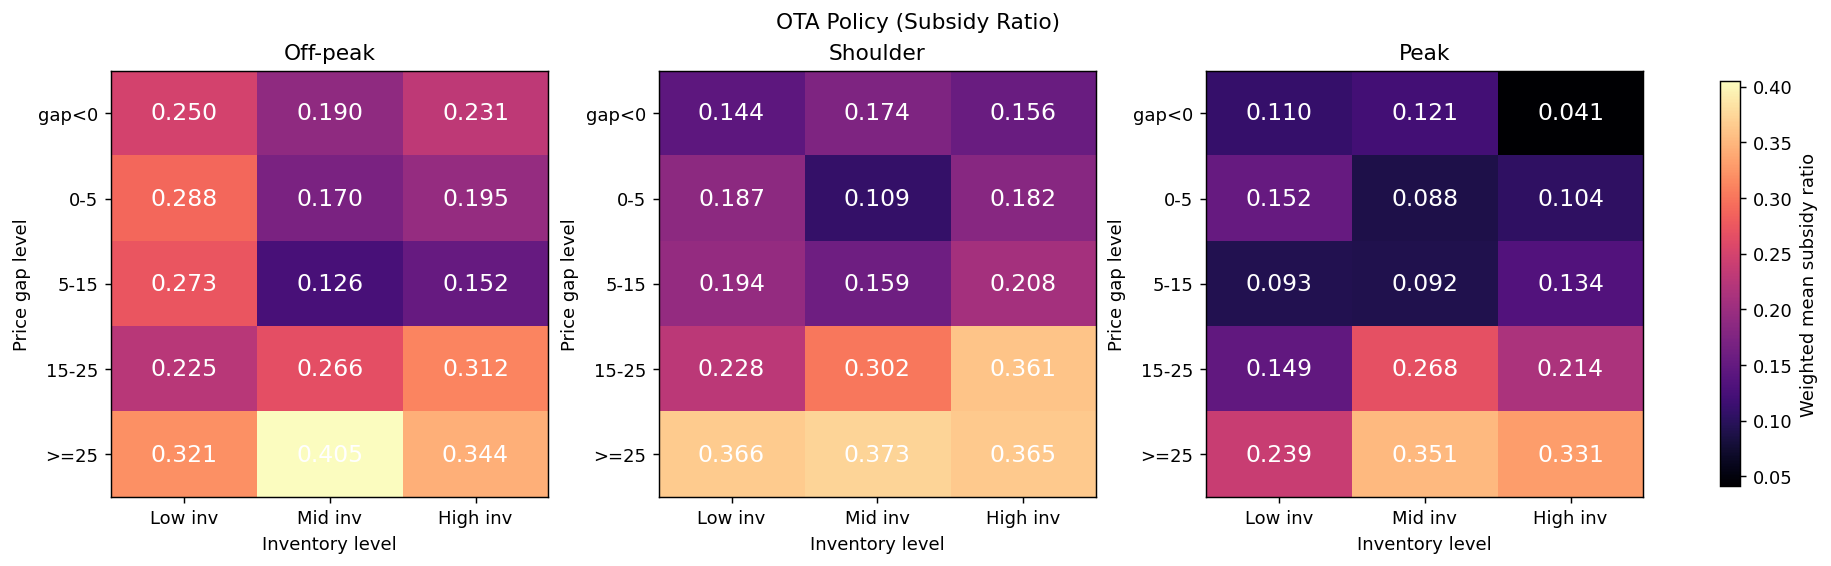

(PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/C2_ota_subsidy_heatmap_weighted.png'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/C2_ota_subsidy_heatmap_weighted.pdf'))

In [17]:
def ota_decode_state(state_idx: int, n_stages: int):
    stage_id = state_idx % n_stages
    base = state_idx // n_stages

    weekday = base % 2
    base //= 2

    season = base % 3
    base //= 3

    inventory_level = base % 3
    base //= 3

    price_gap_level = base
    return int(price_gap_level), int(inventory_level), int(season), int(weekday), int(stage_id)

gap_levels = [0, 1, 2, 3, 4]
inv_levels = [0, 1, 2]
season_levels = [0, 1, 2]

gap_name = {
    0: "gap<0",
    1: "0-5",
    2: "5-15",
    3: "15-25",
    4: ">=25",
}

def ota_weighted_mats(means: dict, visits: dict, n_stages: int):
    mats = {s: np.full((len(gap_levels), len(inv_levels)), np.nan, dtype=float) for s in season_levels}
    mats_cnt = {s: np.zeros((len(gap_levels), len(inv_levels)), dtype=int) for s in season_levels}

    acc = {}
    for state_idx, val in means.items():
        c = int(visits.get(state_idx, 0))
        if c < MIN_VISITS_PER_STATE:
            continue

        gap, inv, season, weekday, stage = ota_decode_state(state_idx, n_stages)
        if gap not in gap_levels or inv not in inv_levels or season not in season_levels:
            continue

        key = (season, gap, inv)
        if key not in acc:
            acc[key] = {"sum": 0.0, "cnt": 0}
        acc[key]["sum"] += float(val) * c
        acc[key]["cnt"] += c

    for (season, gap, inv), v in acc.items():
        if v["cnt"] < MIN_TOTAL_VISITS_PER_CELL:
            continue
        r = gap_levels.index(gap)
        c = inv_levels.index(inv)
        mats[season][r, c] = v["sum"] / v["cnt"]
        mats_cnt[season][r, c] = v["cnt"]

    return mats, mats_cnt

ota_means, ota_visits, _, _ = load_means_and_visits(ota_path)

ota_mats, ota_mats_cnt = ota_weighted_mats(ota_means, ota_visits, N_STAGES)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

vmin = np.nanmin([np.nanmin(ota_mats[s]) for s in season_levels])
vmax = np.nanmax([np.nanmax(ota_mats[s]) for s in season_levels])

for i, season in enumerate(season_levels):
    ax = axes[i]
    im = ax.imshow(ota_mats[season], vmin=vmin, vmax=vmax, cmap="magma", aspect="auto")
    ax.set_title(season_name[season])
    ax.set_xticks(range(len(inv_levels)), labels=inv_name)
    ax.set_yticks(range(len(gap_levels)), labels=[gap_name[g] for g in gap_levels])
    ax.set_xlabel("Inventory level")
    ax.set_ylabel("Price gap level")

    for r in range(len(gap_levels)):
        for c in range(len(inv_levels)):
            v = ota_mats[season][r, c]
            cnt = ota_mats_cnt[season][r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:.3f}", ha="center", va="center", color="white", fontsize=13)

fig.suptitle(
    f"OTA Policy (Subsidy Ratio)",
    y=1.05
)

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label("Weighted mean subsidy ratio")

save_png = FIG_DIR / "C2_ota_subsidy_heatmap_weighted.png"
save_pdf = FIG_DIR / "C2_ota_subsidy_heatmap_weighted.pdf"
fig.savefig(save_png, dpi=300)
fig.savefig(save_pdf, dpi=300)
plt.show()

save_png, save_pdf

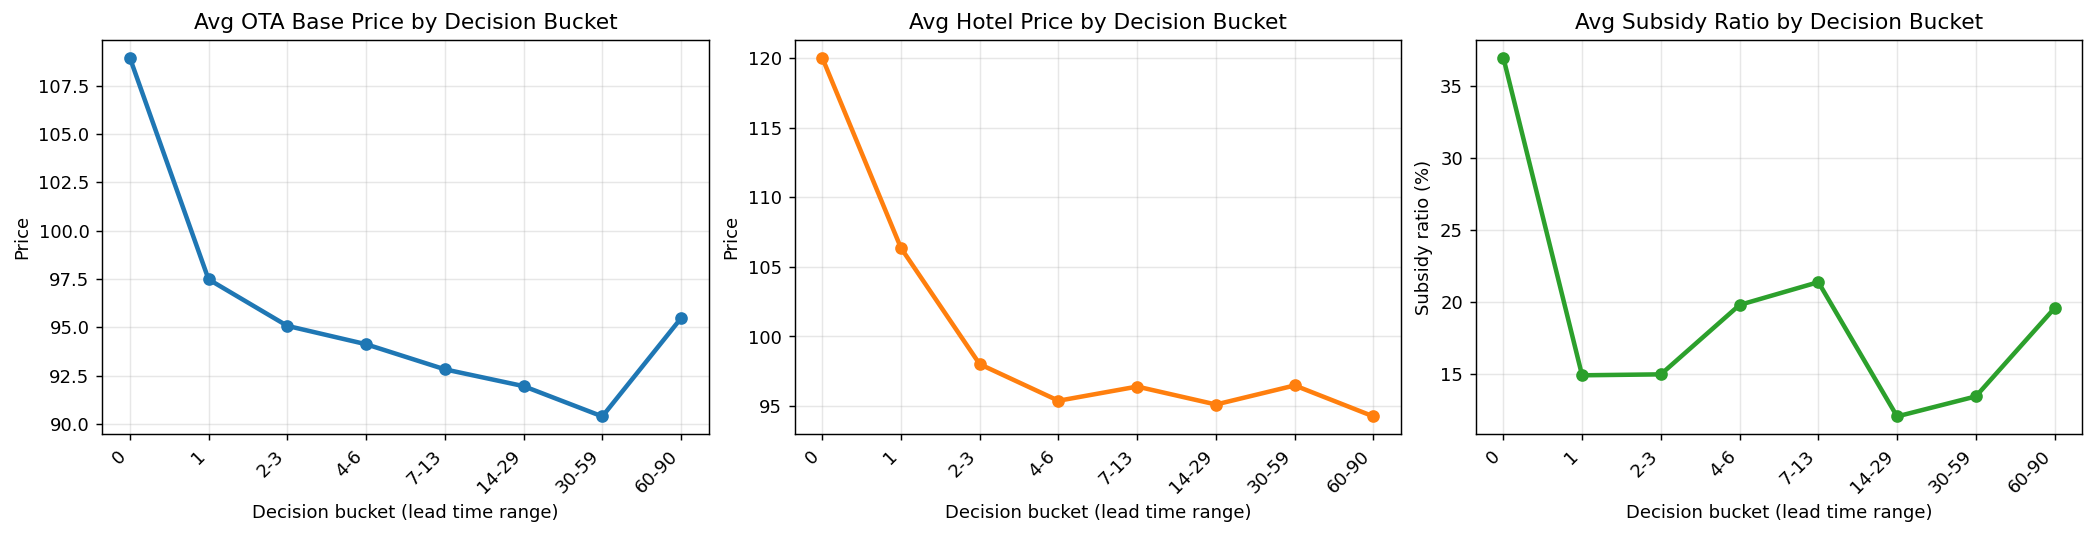

(PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/C3_bucket_avg_online_offline_subsidy.png'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/C3_bucket_avg_online_offline_subsidy.pdf'))

In [18]:
from pathlib import Path
import json
import ast
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing")
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "experiment1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CAPACITY = 200
DECISION_BUCKETS = "0|1|2-3|4-6|7-13|14-29|30-59|60-90"

MIN_VISITS_PER_STATE = 5
MIN_TOTAL_VISITS_PER_STAGE = 50


def newest_file(paths):
    paths = list(paths)
    if not paths:
        return None
    return max(paths, key=lambda p: p.stat().st_mtime)


def find_latest_model_file(kind: str, capacity: int):
    patterns = [
        f"{kind}_cap{capacity}_*_agent_*.json",
        f"{kind}_agent_*.json",
    ]
    for pat in patterns:
        cand = list(MODELS_DIR.glob(pat))
        if cand:
            return newest_file(cand)
    return None


def _parse_int_key(k):
    if isinstance(k, int):
        return k
    if isinstance(k, str) and k.strip().isdigit():
        return int(k.strip())
    if isinstance(k, str):
        try:
            obj = ast.literal_eval(k)
            if isinstance(obj, int):
                return int(obj)
        except Exception:
            return None
    return None


def load_means_and_visits(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means_key = None
    visits_key = None
    for k, v in d.items():
        if isinstance(v, dict) and ("means" in k.lower()):
            means_key = k
        if isinstance(v, dict) and (("visit" in k.lower()) or ("state_visit" in k.lower())):
            visits_key = k

    if means_key is None:
        raise ValueError(f"找不到 means 字段: {json_path.name}，keys={list(d.keys())}")

    means_raw = d[means_key]
    means = {}
    for k, v in means_raw.items():
        idx = _parse_int_key(k)
        if idx is not None:
            means[idx] = float(v)

    visits = {}
    if visits_key is not None:
        visits_raw = d[visits_key]
        for k, v in visits_raw.items():
            idx = _parse_int_key(k)
            if idx is not None:
                visits[idx] = int(v)

    return means, visits


def parse_buckets(spec: str):
    tokens = [t.strip() for t in str(spec).replace(",", "|").split("|") if t.strip()]
    buckets = []
    for t in tokens:
        if "-" in t:
            a, b = t.split("-", 1)
            s, e = int(a), int(b)
        else:
            s = e = int(t)
        buckets.append((s, e))
    buckets.sort(key=lambda x: x[0])
    return buckets


BUCKETS = parse_buckets(DECISION_BUCKETS)
N_STAGES = len(BUCKETS)
stage_labels = [f"{s}-{e}" if s != e else f"{s}" for s, e in BUCKETS]


def hotel_decode_state(state_idx: int, n_stages: int):
    stage_id = state_idx % n_stages
    base = state_idx // n_stages
    inventory_level = base // 6
    rem = base % 6
    season = rem // 2
    weekday = rem % 2
    return int(inventory_level), int(season), int(weekday), int(stage_id)


def ota_decode_state(state_idx: int, n_stages: int):
    stage_id = state_idx % n_stages
    base = state_idx // n_stages

    weekday = base % 2
    base //= 2

    season = base % 3
    base //= 3

    inventory_level = base % 3
    base //= 3

    price_gap_level = base
    return int(price_gap_level), int(inventory_level), int(season), int(weekday), int(stage_id)


def weighted_mean_by_stage(means: dict, visits: dict, n_stages: int, decode_fn):
    stage_sum = np.zeros(n_stages, dtype=float)
    stage_cnt = np.zeros(n_stages, dtype=int)

    for state_idx, val in means.items():
        c = int(visits.get(state_idx, 0))
        if c < MIN_VISITS_PER_STATE:
            continue
        *_, stage_id = decode_fn(int(state_idx), n_stages)
        stage_sum[stage_id] += float(val) * c
        stage_cnt[stage_id] += c

    stage_mean = np.full(n_stages, np.nan, dtype=float)
    for sid in range(n_stages):
        if stage_cnt[sid] >= MIN_TOTAL_VISITS_PER_STAGE:
            stage_mean[sid] = stage_sum[sid] / stage_cnt[sid]

    return stage_mean, stage_cnt


hotel_online_path = find_latest_model_file("hotel_online", CAPACITY)
hotel_offline_path = find_latest_model_file("hotel_offline", CAPACITY)
ota_path = find_latest_model_file("ota", CAPACITY)

if hotel_online_path is None or hotel_offline_path is None or ota_path is None:
    raise FileNotFoundError(f"找不到模型文件：hotel_online={hotel_online_path}, hotel_offline={hotel_offline_path}, ota={ota_path}")

online_means, online_visits = load_means_and_visits(hotel_online_path)
offline_means, offline_visits = load_means_and_visits(hotel_offline_path)
ota_means, ota_visits = load_means_and_visits(ota_path)

online_stage_mean, online_stage_cnt = weighted_mean_by_stage(online_means, online_visits, N_STAGES, hotel_decode_state)
offline_stage_mean, offline_stage_cnt = weighted_mean_by_stage(offline_means, offline_visits, N_STAGES, hotel_decode_state)
ota_stage_mean, ota_stage_cnt = weighted_mean_by_stage(ota_means, ota_visits, N_STAGES, ota_decode_state)

x = np.arange(N_STAGES)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

axes[0].plot(x, online_stage_mean, marker="o", linewidth=2.5)
axes[0].set_title("Avg OTA Base Price by Decision Bucket")
axes[0].set_xlabel("Decision bucket (lead time range)")
axes[0].set_ylabel("Price")
axes[0].set_xticks(x, stage_labels, rotation=45, ha="right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, offline_stage_mean, marker="o", linewidth=2.5, color="tab:orange")
axes[1].set_title("Avg Hotel Price by Decision Bucket")
axes[1].set_xlabel("Decision bucket (lead time range)")
axes[1].set_ylabel("Price")
axes[1].set_xticks(x, stage_labels, rotation=45, ha="right")
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, ota_stage_mean * 100, marker="o", linewidth=2.5, color="tab:green")
axes[2].set_title("Avg Subsidy Ratio by Decision Bucket")
axes[2].set_xlabel("Decision bucket (lead time range)")
axes[2].set_ylabel("Subsidy ratio (%)")
axes[2].set_xticks(x, stage_labels, rotation=45, ha="right")
axes[2].grid(True, alpha=0.3)

#fig.suptitle(
#    f"C3 Decision-bucket Averages (weighted by visits, cap={CAPACITY})",
#    y=1.08,
#)

save_png = FIG_DIR / "C3_bucket_avg_online_offline_subsidy.png"
save_pdf = FIG_DIR / "C3_bucket_avg_online_offline_subsidy.pdf"
fig.savefig(save_png, dpi=300)
fig.savefig(save_pdf, dpi=300)
plt.show()

save_png, save_pdf

In [19]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing").resolve()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd =", Path.cwd())
print("sys.path[0] =", sys.path[0])

cwd = /Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing
sys.path[0] = /Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing


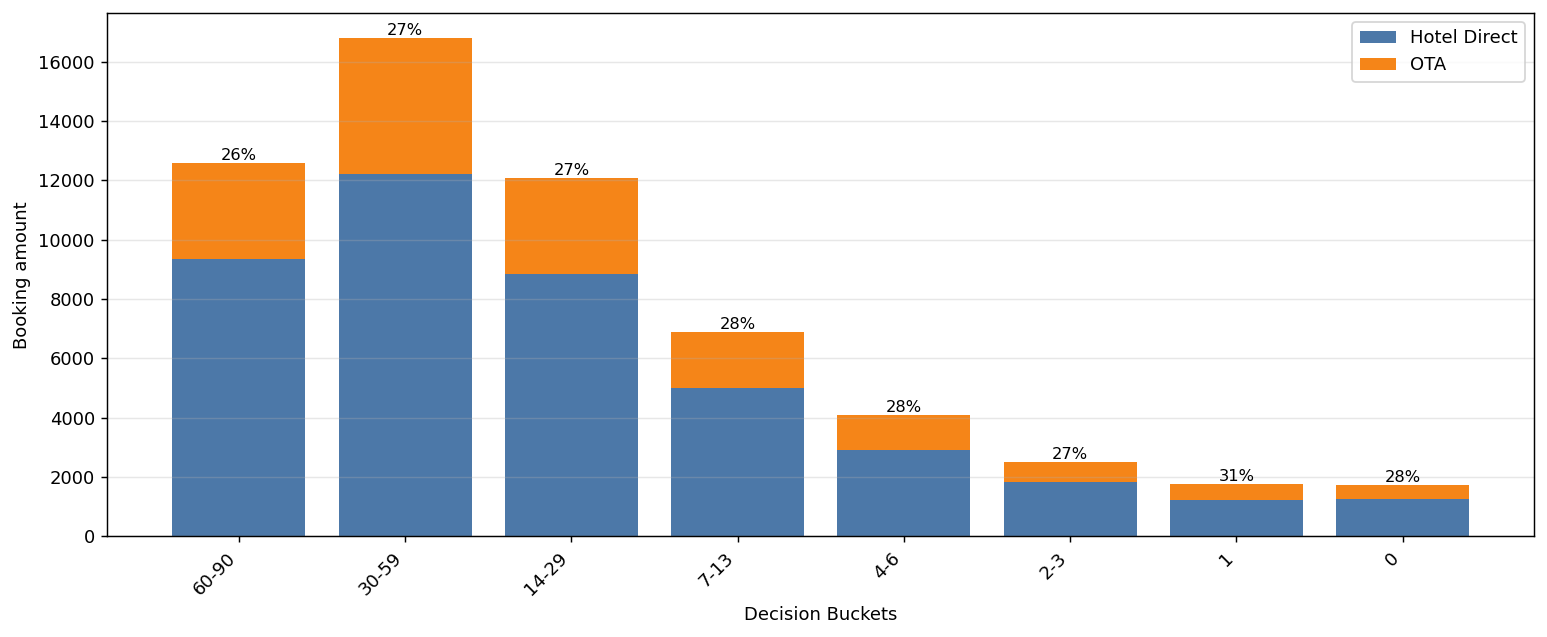

(PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/Fig6_bucket_booking_volume_market_share.png'),
 PosixPath('/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/figures/experiment1/Fig6_bucket_booking_volume_market_share.pdf'))

In [20]:
from pathlib import Path
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing")
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "experiment1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROJECT_ROOT / "datasets" / "hotel_bookings.csv"

CAPACITY = 200
BOOKING_WINDOW_DAYS = 91
DECISION_BUCKETS = "0|1|2-3|4-6|7-13|14-29|30-59|60-90"

COMMISSION_RATE = 0.20
MIN_VISITS_PER_STATE = 5

def newest_file(paths):
    paths = list(paths)
    if not paths:
        return None
    return max(paths, key=lambda p: p.stat().st_mtime)

def find_latest_model_file(kind: str, capacity: int):
    patterns = [
        f"{kind}_cap{capacity}_*_agent_*.json",
        f"{kind}_agent_*.json",
    ]
    for pat in patterns:
        cand = list(MODELS_DIR.glob(pat))
        if cand:
            return newest_file(cand)
    return None

def _parse_int_key(k):
    if isinstance(k, int):
        return k
    if isinstance(k, str) and k.strip().isdigit():
        return int(k.strip())
    if isinstance(k, str):
        try:
            obj = ast.literal_eval(k)
            if isinstance(obj, int):
                return int(obj)
        except Exception:
            return None
    return None

def load_means_and_visits(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means_key = None
    visits_key = None
    for k, v in d.items():
        if isinstance(v, dict) and ("means" in k.lower()):
            means_key = k
        if isinstance(v, dict) and (("visit" in k.lower()) or ("state_visit" in k.lower())):
            visits_key = k

    if means_key is None:
        raise ValueError(f"找不到 means 字段: {json_path.name}，keys={list(d.keys())}")

    means = {}
    for k, v in d[means_key].items():
        idx = _parse_int_key(k)
        if idx is not None:
            means[idx] = float(v)

    visits = {}
    if visits_key is not None:
        for k, v in d[visits_key].items():
            idx = _parse_int_key(k)
            if idx is not None:
                visits[idx] = int(v)

    return means, visits

def parse_buckets(spec: str, n: int):
    tokens = [t.strip() for t in str(spec).replace(",", "|").split("|") if t.strip()]
    buckets = []
    for t in tokens:
        if "-" in t:
            a, b = t.split("-", 1)
            s, e = int(a), int(b)
        else:
            s = e = int(t)
        buckets.append((s, e))
    buckets.sort(key=lambda x: x[0])
    if buckets[0][0] != 0 or buckets[-1][1] != n - 1:
        raise ValueError("Buckets必须覆盖[0, booking_window_days-1]并且连续")
    for i in range(1, len(buckets)):
        if buckets[i][0] != buckets[i-1][1] + 1:
            raise ValueError("Buckets必须连续不间断")
    return buckets

BUCKETS = parse_buckets(DECISION_BUCKETS, BOOKING_WINDOW_DAYS)
N_STAGES = len(BUCKETS)

bucket_of_offset = [0] * BOOKING_WINDOW_DAYS
for sid, (s, e) in enumerate(BUCKETS):
    for off in range(s, e + 1):
        bucket_of_offset[off] = sid

bucket_labels = [f"{s}-{e}" if s != e else f"{s}" for s, e in BUCKETS]

def hotel_state_idx(env_state: dict, stage_id: int, n_stages: int):
    inv = int(env_state.get("inventory_level", 2))
    season = int(env_state.get("season", 0))
    weekday = int(env_state.get("weekday", 0))
    base = inv * 6 + season * 2 + weekday
    return base * n_stages + int(stage_id)

def ota_price_gap_level(pob: float, pof: float):
    gap = float(pob) - float(pof)
    if gap < 0:
        return 0
    if gap < 5:
        return 1
    if gap < 15:
        return 2
    if gap < 25:
        return 3
    return 4

def ota_state_idx(pob: float, pof: float, env_state: dict, stage_id: int, n_stages: int):
    gap_level = ota_price_gap_level(pob, pof)
    inv = int(env_state.get("inventory_level", 2))
    season = int(env_state.get("season", 0))
    weekday = int(env_state.get("weekday", 0))
    base = (gap_level * 3 * 3 * 2) + (inv * 3 * 2) + (season * 2) + weekday
    return base * n_stages + int(stage_id)

def deterministic_action(means: dict, visits: dict, state_idx: int, default_value: float):
    c = int(visits.get(state_idx, 0))
    if c < MIN_VISITS_PER_STATE:
        return default_value
    return float(means.get(state_idx, default_value))

hotel_online_path = find_latest_model_file("hotel_online", CAPACITY)
hotel_offline_path = find_latest_model_file("hotel_offline", CAPACITY)
ota_path = find_latest_model_file("ota", CAPACITY)

if hotel_online_path is None or hotel_offline_path is None or ota_path is None:
    raise FileNotFoundError(f"找不到模型文件：{hotel_online_path}, {hotel_offline_path}, {ota_path}")

hotel_online_means, hotel_online_visits = load_means_and_visits(hotel_online_path)
hotel_offline_means, hotel_offline_visits = load_means_and_visits(hotel_offline_path)
ota_means, ota_visits = load_means_and_visits(ota_path)

DEFAULT_ONLINE_BASE = 130.0
DEFAULT_OFFLINE = 130.0
DEFAULT_SUBSIDY_RATIO = 0.3

historical_data = pd.read_csv(DATA_PATH)
historical_data = historical_data[historical_data["hotel"] == "City Hotel"].copy()

from src.environment.hotel_env import HotelEnvironment

env = HotelEnvironment(
    initial_inventory=CAPACITY,
    historical_data=historical_data,
    booking_window_days=BOOKING_WINDOW_DAYS,
)

env.reset()

price_online_base_by_offset = [DEFAULT_ONLINE_BASE] * BOOKING_WINDOW_DAYS
price_offline_by_offset = [DEFAULT_OFFLINE] * BOOKING_WINDOW_DAYS
subsidy_ratio_by_offset = [DEFAULT_SUBSIDY_RATIO] * BOOKING_WINDOW_DAYS

bucket_bookings_online = np.zeros(N_STAGES, dtype=int)
bucket_bookings_offline = np.zeros(N_STAGES, dtype=int)

trigger_offsets = sorted({int(e) for _, e in BUCKETS if 0 <= int(e) < BOOKING_WINDOW_DAYS})

# 初始化：每个bucket用其末端offset的状态做一次决策，并填充整个bucket
for sid, (s, e) in enumerate(BUCKETS):
    ref_off = int(e)
    st = dict(env._get_state_for_day_offset(ref_off))
    h_idx = hotel_state_idx(st, sid, N_STAGES)

    pob = deterministic_action(hotel_online_means, hotel_online_visits, h_idx, DEFAULT_ONLINE_BASE)
    pof = deterministic_action(hotel_offline_means, hotel_offline_visits, h_idx, DEFAULT_OFFLINE)

    o_idx = ota_state_idx(pob, pof, st, sid, N_STAGES)
    sr = deterministic_action(ota_means, ota_visits, o_idx, DEFAULT_SUBSIDY_RATIO)
    sr = float(np.clip(sr, 0.0, 0.8))

    for off in range(s, e + 1):
        price_online_base_by_offset[off] = float(pob)
        price_offline_by_offset[off] = float(pof)
        subsidy_ratio_by_offset[off] = float(sr)

# 跑一个 evaluation episode：365天
for day in range(365):
    # 桶边界触发：更新这些offset的报价/补贴（保持与训练逻辑一致）
    for off in trigger_offsets:
        sid = bucket_of_offset[off]
        st = dict(env._get_state_for_day_offset(off))
        h_idx = hotel_state_idx(st, sid, N_STAGES)

        pob = deterministic_action(hotel_online_means, hotel_online_visits, h_idx, DEFAULT_ONLINE_BASE)
        pof = deterministic_action(hotel_offline_means, hotel_offline_visits, h_idx, DEFAULT_OFFLINE)

        o_idx = ota_state_idx(pob, pof, st, sid, N_STAGES)
        sr = deterministic_action(ota_means, ota_visits, o_idx, DEFAULT_SUBSIDY_RATIO)
        sr = float(np.clip(sr, 0.0, 0.8))

        price_online_base_by_offset[off] = float(pob)
        price_offline_by_offset[off] = float(pof)
        subsidy_ratio_by_offset[off] = float(sr)

    price_online_final_window = [
        price_online_base_by_offset[i] - price_online_base_by_offset[i] * COMMISSION_RATE * subsidy_ratio_by_offset[i]
        for i in range(BOOKING_WINDOW_DAYS)
    ]
    actions_window = [[price_online_final_window[i], price_offline_by_offset[i]] for i in range(BOOKING_WINDOW_DAYS)]

    _, _, done, info = env.step(actions_window)

    bookings_by_day_offset = info.get("bookings_by_day_offset", [])
    max_len = min(len(bookings_by_day_offset), BOOKING_WINDOW_DAYS)

    for off in range(max_len):
        sid = bucket_of_offset[off]
        bo = int(bookings_by_day_offset[off].get("bookings_online", 0))
        bf = int(bookings_by_day_offset[off].get("bookings_offline", 0))
        bucket_bookings_online[sid] += bo
        bucket_bookings_offline[sid] += bf

    if done:
        break

# 画图：横轴从 60-90 到 0（反向）
order = list(range(N_STAGES))[::-1]
x_labels = [bucket_labels[i] for i in order]
ota_vals = bucket_bookings_online[order]
direct_vals = bucket_bookings_offline[order]
total_vals = ota_vals + direct_vals
ota_share = ota_vals / np.maximum(1, total_vals)

x = np.arange(N_STAGES)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, direct_vals, label="Hotel Direct", color="#4C78A8")
ax.bar(x, ota_vals, bottom=direct_vals, label="OTA", color="#F58518")

for i in range(N_STAGES):
    if total_vals[i] <= 0:
        continue
    ax.text(i, total_vals[i], f"{ota_share[i]*100:.0f}%", ha="center", va="bottom", fontsize=9)

#ax.set_title("Fig 6: Booking Volume & Market Share by Bucket (Stacked)")
ax.set_xlabel("Decision Buckets")
ax.set_ylabel("Booking amount")
ax.set_xticks(x, x_labels, rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

save_png = FIG_DIR / "Fig6_bucket_booking_volume_market_share.png"
save_pdf = FIG_DIR / "Fig6_bucket_booking_volume_market_share.pdf"
fig.tight_layout()
fig.savefig(save_png, dpi=300)
fig.savefig(save_pdf, dpi=300)
plt.show()

save_png, save_pdf